<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW3/HW3_Seq2Seq_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jordan Terwilliger, 801343938, HW3

#Imports

In [118]:
import torch
import torch.nn as nn
import torch.functional as F

import matplotlib.pyplot as plt
import numpy as np

import requests

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from torch import optim

torch.manual_seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [119]:
url = "https://raw.githubusercontent.com/JordanTerwilliger/Intro-to-Deep-Learning/refs/heads/main/HW3/vast_english_french.txt"
response = requests.get(url)
text = response.text  # This is the entire text data

#Preprocessing

In [120]:
max_length = 0
def tokenize_and_pad(sentences, vocab):
    # Calculate the maximum sentence length for padding
    global max_length
    max_length = max(len(sentence.split(' ')) for sentence in sentences) + 2  # +2 for SOS and EOS tokens
    tokenized_sentences = []
    for sentence in sentences:
        # Convert each sentence to a list of indices, adding SOS and EOS tokens
        tokens = [vocab.word2index["<SOS>"]] + [vocab.word2index[word] for word in sentence.split(' ')] + [vocab.word2index["<EOS>"]]
        # Pad sentences to the maximum length
        padded_tokens = tokens + [vocab.word2index["<PAD>"]] * (max_length - len(tokens))
        tokenized_sentences.append(padded_tokens)
    return torch.tensor(tokenized_sentences, dtype=torch.long)

In [121]:
# Vocabulary class to handle mapping between words and numerical indices
class Vocabulary:
  def __init__(self):
    #Dictionaries for special tokens and reverse
    self.word2index = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2}
    self.index2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>"}
    self.word_count = {}  # Keep track of word frequencies
    self.n_words = 3  # Start counting from 3 to account for special tokens

  def add_sentence(self, sentence):
    # Add all words in a sentence to the vocabulary
      for word in sentence.split(' '):
        self.add_word(word)

  def add_word(self, word):
        # Add a word to the vocabulary
        if word not in self.word2index:
            # Assign a new index to the word and update mappings
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            # Increment word count if the word already exists in the vocabulary
            self.word_count[word] += 1

In [122]:
class EngFrDataset(Dataset):
    def __init__(self, pairs):
        self.eng_vocab = Vocabulary()
        self.fr_vocab = Vocabulary()
        self.pairs = []

        # Process each English-French pair
        for eng, fr in pairs:
            self.eng_vocab.add_sentence(eng)
            self.fr_vocab.add_sentence(fr)
            self.pairs.append((eng, fr))

        # Separate English and French sentences
        self.eng_sentences = [pair[0] for pair in self.pairs]
        self.fr_sentences = [pair[1] for pair in self.pairs]

        # Tokenize and pad sentences
        self.eng_tokens = tokenize_and_pad(self.eng_sentences, self.eng_vocab)
        self.fr_tokens = tokenize_and_pad(self.fr_sentences, self.fr_vocab)

    def __len__(self):
        # Return the number of sentence pairs
        return len(self.pairs)

    def __getitem__(self, idx):
        # Get the tokenized and padded sentences by index
        eng_tokens = self.eng_tokens[idx]
        fr_tokens = self.fr_tokens[idx]
        return eng_tokens, fr_tokens

In [123]:
pairs = [
    tuple(part.strip() for part in line.split('\t')) for line in text.splitlines() if '\t' in line
]

dataset = EngFrDataset(pairs)

train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

idx2w_e = dataset.eng_vocab.index2word
idx2w_f = dataset.fr_vocab.index2word
print(idx2w_e)
print(idx2w_f)
batch_size = 256
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)


{0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: 'I', 4: 'am', 5: 'cold', 6: 'You', 7: 'are', 8: 'tired', 9: 'He', 10: 'is', 11: 'hungry', 12: 'She', 13: 'happy', 14: 'We', 15: 'friends', 16: 'They', 17: 'students', 18: 'The', 19: 'cat', 20: 'sleeping', 21: 'sun', 22: 'shining', 23: 'love', 24: 'music', 25: 'speaks', 26: 'French', 27: 'fluently', 28: 'enjoys', 29: 'reading', 30: 'books', 31: 'play', 32: 'soccer', 33: 'every', 34: 'weekend', 35: 'movie', 36: 'starts', 37: 'at', 38: '7', 39: 'PM', 40: 'wears', 41: 'a', 42: 'red', 43: 'dress', 44: 'cook', 45: 'dinner', 46: 'together', 47: 'drives', 48: 'blue', 49: 'car', 50: 'visit', 51: 'museums', 52: 'often', 53: 'restaurant', 54: 'serves', 55: 'delicious', 56: 'food', 57: 'studies', 58: 'mathematics', 59: 'university', 60: 'watch', 61: 'movies', 62: 'on', 63: 'Fridays', 64: 'listens', 65: 'to', 66: 'while', 67: 'jogging', 68: 'travel', 69: 'around', 70: 'the', 71: 'world', 72: 'book', 73: 'table', 74: 'dances', 75: 'gracefully', 76: 'celebrate'

#Model Creation

In [124]:
class Encoder(nn.Module):
  def __init__(self, input_size, hidden_size, dropout_p = 0.1):
    super(Encoder,self).__init__()

    """
    Args :
          input_size: The size of our English vocab
          hidden_size: The size of our hidden dimension
          dropout_p: The dropout rate
    """
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.dropout_p = dropout_p


    self.embedding = nn.Embedding(self.input_size, self.hidden_size) #num_embeddings, embedding_dim
    self.rnn = nn.GRU(self.hidden_size, self.hidden_size, batch_first=True) #the embedding dimension = hidden dimension
    self.dropout = nn.Dropout(self.dropout_p)


  def initHidden(self):
      # Shape: (num_layers, batch_size=1, hidden_size)
      return torch.zeros(1, 1, self.hidden_size, device=device)

  def forward(self, input_tensor):
    embedded = self.dropout(self.embedding(input_tensor))
    output, hidden = self.rnn(embedded)
    return output, hidden #Hidden is the input to the decoder, Input -> Encoder -> Encoder Output + Hidden State -> Decoder -> Output


class BahdanauAttention(nn.Module):
  def __init__(self, hidden_size, dropout_p=0.1):
      super(BahdanauAttention, self).__init__()
      self.Wa = nn.Linear(hidden_size, hidden_size)
      self.Ua = nn.Linear(hidden_size, hidden_size)
      self.Va = nn.Linear(hidden_size, 1)

      self.softmax = nn.Softmax(dim=-1)
      # Added dropout for regularization on attention weights
      self.dropout = nn.Dropout(dropout_p)

  def forward(self, query, keys):
      scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
      scores = scores.transpose(1, 2)  # shape of scores = [B, 1, S]

      weights = self.softmax(scores)
      weights = self.dropout(weights)
      context = torch.bmm(weights, keys)
      return context, weights


class AttnDecoder(nn.Module):
  def __init__(self, output_size, hidden_size, dropout_p=0.1):
    super(AttnDecoder, self).__init__()
    self.hidden_size = hidden_size
    self.output_size = output_size
    self.dropout_p = dropout_p

    self.embedding = nn.Embedding(self.output_size, self.hidden_size)
    self.dropout = nn.Dropout(self.dropout_p)

    self.attention = BahdanauAttention(self.hidden_size)
    self.rnn = nn.GRU(hidden_size * 2, hidden_size, batch_first=True)
    self.out = nn.Linear(hidden_size, output_size)

  def forward(self, input_tensor, hidden, encoder_outputs):
    embedded = self.dropout(self.embedding(input_tensor))

    # hidden.transpose(0, 1) changes shape from [1, batch_size, hidden_size] to [batch_size, 1, hidden_size] for the query
    context, attn_weights = self.attention(hidden.transpose(0, 1), encoder_outputs)

    rnn_input = torch.cat((embedded, context), dim=-1)
    rnn_output, hidden = self.rnn(rnn_input, hidden)

    output = self.out(rnn_output.squeeze(1))

    return output, hidden, attn_weights

In [125]:
input_size = len(dataset.eng_vocab.index2word)
hidden_size = 256
output_size = len(dataset.fr_vocab.index2word)

encoder = Encoder(input_size, hidden_size).to(device)
decoder = AttnDecoder(output_size, hidden_size).to(device)

learning_rate = 0.001
encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

#Training Loop


In [126]:
PAD = 0
SOS = 1
EOS = 2

def train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
  encoder.train()
  decoder.train()

  encoder_optimizer.zero_grad()
  decoder_optimizer.zero_grad()

  batch_size = input_tensor.size(0)
  target_length = target_tensor.size(1)
  loss = 0

  # 1. Pass the entire batch through the encoder in ONE step
  encoder_outputs, encoder_hidden = encoder(input_tensor)

  # 2. Setup decoder input: A batch of <SOS> tokens
  decoder_input = torch.full((batch_size, 1), SOS, device=device)
  decoder_hidden = encoder_hidden

  # 3. Step through the target sequence length
  for di in range(target_length):
    decoder_output, decoder_hidden,_ = decoder(decoder_input, decoder_hidden, encoder_outputs)

    # Calculate loss for this timestep across the whole batch
    loss += criterion(decoder_output, target_tensor[:, di])

    _, topi = decoder_output.topk(1) # Get the index of the best prediction
    decoder_input = topi.detach() # Detach from history as input

  loss.backward()
  encoder_optimizer.step()
  decoder_optimizer.step()

  return loss.item() / target_length


def test(input_tensor, target_tensor, encoder, decoder, criterion):
    encoder.eval()
    decoder.eval()

    batch_size = input_tensor.size(0)
    target_length = target_tensor.size(1)
    correct = 0
    total_tokens = 0  # count only non-pad tokens

    with torch.no_grad():
        encoder_output, encoder_hidden = encoder(input_tensor)

        decoder_input = torch.full((batch_size, 1), SOS, device=device)
        decoder_hidden = encoder_hidden

        decoder_outputs = []

        for di in range(1, target_length):
            decoder_output, decoder_hidden,_ = decoder(decoder_input, decoder_hidden, encoder_output)
            decoder_outputs.append(decoder_output)

            _, topi = decoder_output.topk(1)
            decoder_input = topi.detach()

            target_step = target_tensor[:, di]
            mask = target_step != PAD
            correct += ((topi.squeeze(1) == target_step) & mask).sum().item()
            total_tokens += mask.sum().item()

        decoder_outputs = torch.stack(decoder_outputs, dim=1)
        targets = target_tensor[:, 1:]
        val_loss = criterion(decoder_outputs.reshape(-1, decoder_outputs.size(-1)), targets.reshape(-1))

    accuracy = correct / total_tokens if total_tokens > 0 else 0.0
    return val_loss.item(), accuracy

In [127]:
epochs = 125
val_loss_list = []
train_loss_list = []

print("Starting Training...")
for epoch in range(epochs):
  total_loss = 0
  total_val_loss = 0
  total_val_accuracy = 0

  for input_tensor, target_tensor in train_loader:
    input_tensor = input_tensor.to(device)
    target_tensor = target_tensor.to(device)
    loss = train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
    total_loss += loss
  train_loss_list.append(total_loss / len(train_loader))

  for input_tensor, target_tensor in test_loader:
    input_tensor = input_tensor.to(device)
    target_tensor = target_tensor.to(device)
    val_loss, val_accuracy = test(input_tensor, target_tensor, encoder, decoder, criterion)
    total_val_loss += val_loss
    total_val_accuracy += val_accuracy

  val_loss_list.append(total_val_loss / len(test_loader))
  print(f"Epoch {epoch}, Train Loss: {(total_loss / len(train_loader)):.4f}, Val Loss: {(total_val_loss / len(test_loader)):.4f}, Val Accuracy: {(total_val_accuracy / len(test_loader)):.4f}")

Starting Training...
Epoch 0, Train Loss: 6.8505, Val Loss: 5.4756, Val Accuracy: 0.0000
Epoch 1, Train Loss: 5.1775, Val Loss: 3.8561, Val Accuracy: 0.0000
Epoch 2, Train Loss: 4.0946, Val Loss: 3.6371, Val Accuracy: 0.0000
Epoch 3, Train Loss: 3.8008, Val Loss: 3.4839, Val Accuracy: 0.0000
Epoch 4, Train Loss: 3.5235, Val Loss: 3.5869, Val Accuracy: 0.0000
Epoch 5, Train Loss: 3.3576, Val Loss: 3.2951, Val Accuracy: 0.0000
Epoch 6, Train Loss: 3.2354, Val Loss: 3.2175, Val Accuracy: 0.0000
Epoch 7, Train Loss: 3.1903, Val Loss: 3.2017, Val Accuracy: 0.0000
Epoch 8, Train Loss: 3.1297, Val Loss: 3.2520, Val Accuracy: 0.0282
Epoch 9, Train Loss: 3.0717, Val Loss: 3.2672, Val Accuracy: 0.0282
Epoch 10, Train Loss: 3.0235, Val Loss: 3.2136, Val Accuracy: 0.0196
Epoch 11, Train Loss: 2.9859, Val Loss: 3.2453, Val Accuracy: 0.0012
Epoch 12, Train Loss: 2.9453, Val Loss: 3.1995, Val Accuracy: 0.0196
Epoch 13, Train Loss: 2.9174, Val Loss: 3.2105, Val Accuracy: 0.0196
Epoch 14, Train Loss: 2

In [128]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def BLEU(encoder, decoder, dataloader, n_examples=5):
  total_bleu_score = 0.0
  total_sentences = 0
  chencherry = SmoothingFunction()
  examples_printed = 0

  # Ensure models are in evaluation mode
  encoder.eval()
  decoder.eval()

  with torch.no_grad():
    for input_tensor, target_tensor in dataloader:
      input_tensor = input_tensor.to(device)
      target_tensor = target_tensor.to(device)

      batch_size = input_tensor.size(0)

      # 1. Pass entire batch through Encoder
      encoder_outputs, encoder_hidden = encoder(input_tensor)

      # 2. Setup Decoder for the batch
      decoder_input = torch.full((batch_size, 1), SOS, device=device)
      decoder_hidden = encoder_hidden

      # Tensor to store predictions for the whole batch: [batch_size, 20]
      max_gen_length = 20
      batch_predictions = torch.zeros(batch_size, max_gen_length, dtype=torch.long, device=device)

      # 3. Generate step (Process the whole batch at once)
      for di in range(max_gen_length):
          decoder_output, decoder_hidden, decoder_attention = decoder(decoder_input, decoder_hidden, encoder_outputs)
          _, topi = decoder_output.topk(1) # topi shape: [batch_size, 1]

          # Store the predicted token for each sequence in the batch
          batch_predictions[:, di] = topi.squeeze(1)

          # Use predictions as the next input
          decoder_input = topi.detach()

      # 4. Convert to strings and calculate BLEU for each sentence in the batch
      for b in range(batch_size):
        inp_seq = input_tensor[b]
        tgt_seq = target_tensor[b]
        pred_seq = batch_predictions[b]

        # Helper function to convert indices to strings properly
        def to_string(seq, vocab, is_pred=False):
            words = []
            for idx in seq:
                val = idx.item()
                # For predictions, we MUST stop at the first EOS token
                if val == EOS and is_pred:
                    break
                # Ignore special tokens in the final readable string
                if val not in (SOS, EOS, PAD):
                    words.append(vocab[val])
            return ' '.join(words)

        input_string = to_string(inp_seq, idx2w_e)
        target_string = to_string(tgt_seq, idx2w_f)
        predicted_string = to_string(pred_seq, idx2w_f, is_pred=True)

        # --- EVALUATION: BLEU Score ---
        reference_tokens = [target_string.split()]
        candidate_tokens = predicted_string.split()

        bleu = sentence_bleu(reference_tokens, candidate_tokens, smoothing_function=chencherry.method1)
        total_bleu_score += bleu
        total_sentences += 1

        # Print the first n_examples
        if examples_printed < n_examples:
          match_status = "PASS" if predicted_string == target_string else "FAIL"
          print(f'Input: {input_string:<20} | Target: {target_string:<20} | Predicted: {predicted_string:<20} | Match: {match_status:<4} | BLEU: {bleu:.4f}')
          examples_printed += 1

  # Calculate average across all processed sentences
  average_bleu = total_bleu_score / total_sentences
  print(f'\n -> Average Validation BLEU-4 Score : {average_bleu:.4f}')

  return average_bleu

In [129]:
BLEU(encoder, decoder, test_loader)

Input: They are watching a football match | Target: Ils regardent un match de football | Predicted: Ils parlent souvent un de de | Match: FAIL | BLEU: 0.0537
Input: Close the window     | Target: Fermez la fenêtre    | Predicted: Nous marchons le téléphone | Match: FAIL | BLEU: 0.0000
Input: He runs five miles every morning before breakfast | Target: Il court cinq milles tous les matins avant le petit déjeuner | Predicted: Il a terminé des pour de de de les | Match: FAIL | BLEU: 0.0228
Input: We learn something new every day | Target: Nous apprenons quelque chose de nouveau chaque jour | Predicted: Nous avons célébré sa tous les les | Match: FAIL | BLEU: 0.0286
Input: The soup tastes delicious | Target: La soupe est délicieuse | Predicted: Les partagent leurs des | Match: FAIL | BLEU: 0.0000

 -> Average Validation BLEU-4 Score : 0.1054


0.10541594300283393

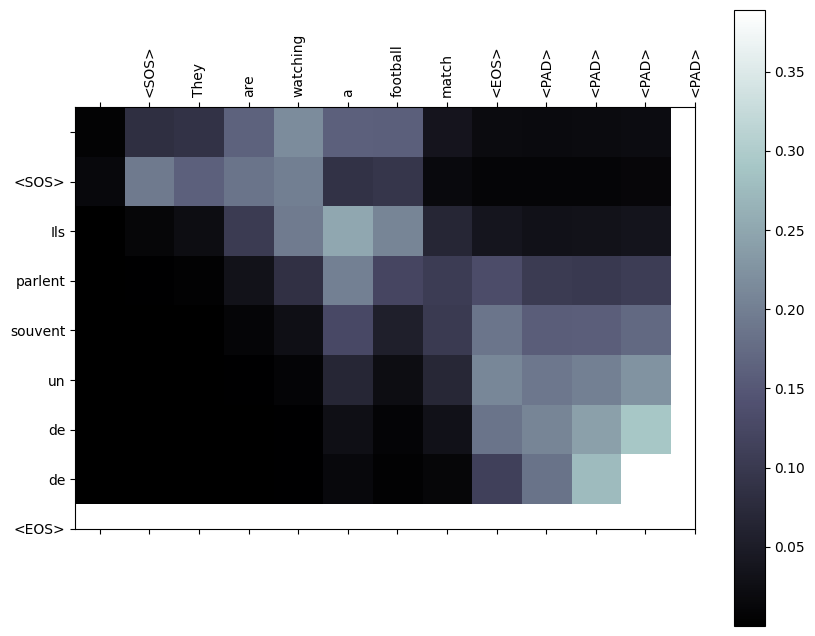

In [130]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def show_attention(input_words, output_words, attentions):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions, cmap='bone')
    fig.colorbar(cax)

    # Set up axes explicitly to prevent UserWarning
    ax.set_xticks(np.arange(len(input_words) + 1))
    ax.set_yticks(np.arange(len(output_words) + 1))

    ax.set_xticklabels([''] + input_words, rotation=90)
    ax.set_yticklabels([''] + output_words)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()

# Get a single sentence from the test loader
input_tensor, target_tensor = next(iter(test_loader))
input_tensor = input_tensor[0:1].to(device) # Shape [1, seq_len]

encoder.eval()
decoder.eval()

with torch.no_grad():
    encoder_outputs, encoder_hidden = encoder(input_tensor)

    decoder_input = torch.full((1, 1), SOS, device=device)
    decoder_hidden = encoder_hidden

    decoded_words = []
    max_gen_length = 20
    decoder_attentions = torch.zeros(max_gen_length, input_tensor.size(1))

    for di in range(max_gen_length):
        decoder_output, decoder_hidden, decoder_attention = decoder(decoder_input, decoder_hidden, encoder_outputs)

        # Save attention weights
        decoder_attentions[di] = decoder_attention.squeeze(0).squeeze(0).cpu()

        _, topi = decoder_output.topk(1)
        val = topi.item()

        if val == EOS:
            decoded_words.append('<EOS>')
            break
        else:
            decoded_words.append(idx2w_f.get(val, "<UNK>"))

        decoder_input = topi.detach()

# Convert input tensor indices to words
input_words = [idx2w_e.get(idx.item(), "<UNK>") for idx in input_tensor.squeeze()]

# Plot the attention map, trimming attentions to the generated length
show_attention(input_words, decoded_words, decoder_attentions[:len(decoded_words)].numpy())


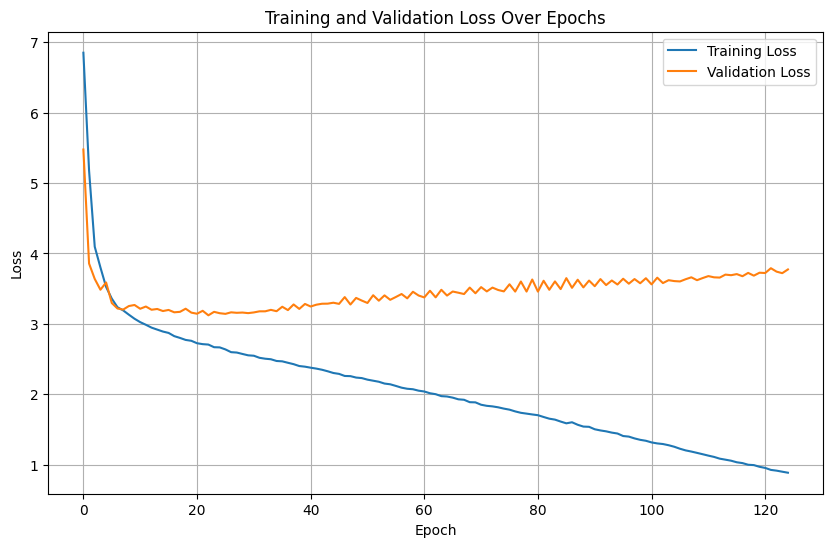

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()